In [3]:
!git clone https://github.com/Kratika246/implicit-grammar.git
%cd /content/implicit-grammar
!pip install -e .

Cloning into 'implicit-grammar'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 28 (delta 9), reused 20 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 1.54 MiB | 19.25 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/implicit-grammar
Obtaining file:///content/implicit-grammar
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 2.9 MB/s e

In [1]:
%cd /content/implicit-grammar
!ls
!python preprocessing/prepare_corpus.py

/content/implicit-grammar
01_character_model.ipynb  preprocessing   README.md  uv.lock
02_mlp_model.ipynb	  pyproject.toml  src
Cloning into 'data/raw/thealgorithms-python'...
remote: Enumerating objects: 24885, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 24885 (delta 6), reused 5 (delta 4), pack-reused 24870 (from 3)
Receiving objects: 100% (24885/24885), 17.77 MiB | 25.81 MiB/s, done.
Resolving deltas: 100% (15395/15395), done.
Raw dataset downloaded.
Found 1577 Python files
Training files: 1261
Evaluation files: 316

Corpus preparation complete!
{
    "total_source_files": 1577,
    "training_files": 1261,
    "heldout_files": 316,
    "training_characters": 3605089,
    "evaluation_functions": 908
}


In [2]:
from pathlib import Path

train_dir = Path("data/processed/train")

train_files = list(train_dir.glob("*.py"))

texts = []

for path in train_files:
    with open(path, "r", encoding="utf-8") as f:
        texts.append(f.read())

print("Number of files:", len(texts))

Number of files: 947


In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
chars = ['<S>', '<E>'] + sorted(list(set("".join(texts))))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
itos
vocab_size = len(itos)
print(vocab_size)

99


In [5]:
block_size = 3
X, Y = [], []
for text in texts:
  print(text)
  context = [0] * block_size
  for ch in "<S>" + text + "E":
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X = torch.tensor(X, dtype=torch.long, device=device)
Y = torch.tensor(Y, dtype=torch.long, device=device)

print(X.device)
print(Y.device)

Streaming output truncated to the last 5000 lines.
_va ---> l
val ---> u
alu ---> e
lue ---> s
ues ---> [
es[ ---> "
s[" ---> K
["K ---> e
"Ke ---> y
Key ---> 1
ey1 ---> 0
y10 ---> "
10" ---> ]
0"] --->  
"]  ---> =
] = ---> =
 == --->  
==  ---> 1
= 1 ---> 0
 10 ---> 

10
 ---> 

0

 ---> 




 ---> d


d ---> e

de ---> f
def --->  
ef  ---> t
f t ---> e
 te ---> s
tes ---> t
est ---> _
st_ ---> s
t_s ---> e
_se ---> a
sea ---> r
ear ---> c
arc ---> h
rch ---> i
chi ---> n
hin ---> g
ing ---> _
ng_ ---> e
g_e ---> m
_em ---> p
emp ---> t
mpt ---> y
pty ---> _
ty_ ---> l
y_l ---> i
_li ---> s
lis ---> t
ist ---> _
st_ ---> r
t_r ---> e
_re ---> t
ret ---> u
etu ---> r
tur ---> n
urn ---> s
rns ---> _
ns_ ---> n
s_n ---> o
_no ---> n
non ---> e
one ---> (
ne( ---> )
e() --->  
()  ---> -
) - ---> >
 -> --->  
->  ---> N
> N ---> o
 No ---> n
Non ---> e
one ---> :
ne: ---> 

e:
 --->  
:
  --->  

   --->  
    --->  
    ---> s
  s ---> k
 sk ---> i
ski ---> p
kip ---> _
ip_ ---> l
p_l

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([3271130, 3]), torch.int64, torch.Size([3271130]), torch.int64)

In [7]:
C = torch.randn((vocab_size, 2), device=device)

In [8]:
F.one_hot(torch.tensor(5, device=device), num_classes=vocab_size).float() @ C

tensor([-0.7915,  0.5219], device='cuda:0')

In [149]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, 2), device=device)
W1 = torch.randn((6, 100), device=device)
b1 = torch.randn(100, device=device)
W2 = torch.randn((100, vocab_size), device=device)
b2 = torch.randn(vocab_size, device=device)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
  p.requires_grad = True

In [144]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lri = []

In [150]:
lri = []
lossi = []
for i in range(len(lrs)):

    ix = torch.randint(0, X.shape[0], (32,), device=device)

    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2

    loss = F.cross_entropy(logits, Y[ix])

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = 0.1

    for p in parameters:
        p.data += -lr * p.grad


In [151]:
loss

tensor(2.2858, device='cuda:0', grad_fn=<NllLossBackward0>)

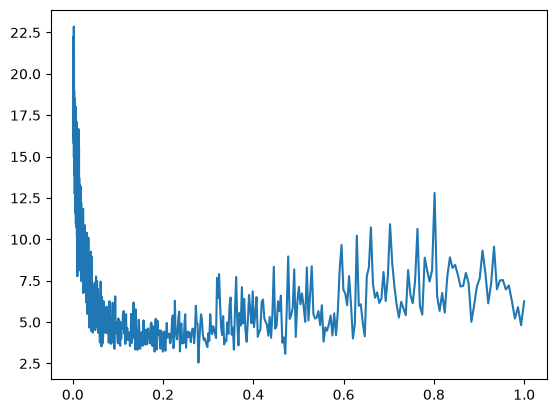

In [148]:
plt.plot(lri, lossi)

In [147]:
import gc
gc.collect()
torch.cuda.empty_cache()